 #  **2.2 Impact Model Fitting**

In this section, we fit price impact models using the in-sample public trading tape.The goal is to estimate how signed market order flow affects future price changes. Following the lecture methodology, we assume that observed price changes can be decomposed into a fundamental price move plus a price impact component:$$\Delta P_t = \Delta S_t + \Delta I_t(Q)$$Since the fundamental price move $\Delta S_t$ is not directly observable, we treat it as noise and estimate the price impact component by regressing observed returns on changes in the model-implied impact state.We fit three impact models:## 1. OW modelThe Obizhaeva–Wang model assumes linear price impact with exponential decay:$$I_{t+\Delta t} = e^{-\beta \Delta t} I_t + \lambda \sigma_i \frac{q_t}{ADV_i}$$where:- $q_t$ is signed traded volume,- $ADV_i$ is the average daily volume of stock $i$,- $\sigma_i$ is the stock-level volatility scale,- $\lambda$ is the impact coefficient,- $\beta$ controls the impact decay speed.## 2. AFS-style modelThe AFS-style model first computes a linear volume-space impact state $J_t$ and then applies a square-root transformation:$$I_t = \operatorname{sign}(J_t)\sqrt{|J_t|}$$This captures the idea that price impact may be concave for larger orders.## 3. Reduced-form dynamic-liquidity modelThe reduced-form model allows liquidity to vary over time. It estimates a local volume state $v_t$ and scales signed order flow by local market activity:$$I_{t+\Delta t} - I_t=-\beta I_t \Delta t+\lambda \sigma_i\frac{q_t}{\sqrt{ADV_i v_t}}$$where $v_t$ is an exponentially weighted estimate of recent unsigned traded volume.For each model, we first compute the normalized impact state using $\lambda = 1$. Then, for a given horizon $h$, we compute the model-implied impact change:$$\Delta_h I_t = I_{t+h} - I_t$$and the realized forward return:$$r_{t,h} = \frac{P_{t+h} - P_t}{P_t}$$We estimate the impact coefficient $\lambda$ from the in-sample data using the regression:$$r_{t,h} = a + \lambda \Delta_h I_t + \varepsilon_t$$The fitted $\lambda$ is then evaluated on both the in-sample month and the out-of-sample month.The outputs of this section are:- fitted $\lambda$ for each stock, model, and half-life;- in-sample $R^2$;- out-of-sample $R^2$;- a grid-search summary over different impact half-lives;- the best half-life for each model, selected using in-sample $R^2$;- CSV files containing the stock-level results, model summary, and best model choices.This completes the baseline coursework requirement of fitting the OW model together with more advanced impact models using the in-sample public trading tape.

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import src.impact_model_fitting

importlib.reload(src.impact_model_fitting)

from src.impact_model_fitting import *

In [2]:
# Load data
result_path = "data/"

train_traded_volume_df = pd.read_csv(
    os.path.join(result_path, "train_traded_volume_201901_20.csv"),
    index_col=[0, 1]
)

test_traded_volume_df = pd.read_csv(
    os.path.join(result_path, "test_traded_volume_201902_20.csv"),
    index_col=[0, 1]
)

train_px_df = pd.read_csv(
    os.path.join(result_path, "train_px_201901_20.csv"),
    index_col=[0, 1]
)

test_px_df = pd.read_csv(
    os.path.join(result_path, "test_px_201902_20.csv"),
    index_col=[0, 1]
)

scaling_df = pd.read_csv(
    os.path.join(result_path, "scaling_201901_20.csv"),
    index_col=0
)

In [4]:
# Ensure columns are sorted time strings
train_traded_volume_df = train_traded_volume_df.sort_index().sort_index(axis=1)
test_traded_volume_df = test_traded_volume_df.sort_index().sort_index(axis=1)
train_px_df = train_px_df.sort_index().sort_index(axis=1)
test_px_df = test_px_df.sort_index().sort_index(axis=1)

In [ ]:
# Fit the model for half-life of 1 hour and horizon of 6 periods (30 minutes)
ow_result_1h = fit_impact_model_once(
    train_traded_volume_df=train_traded_volume_df,
    test_traded_volume_df=test_traded_volume_df,
    train_px_df=train_px_df,
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    model_type="ow",
    half_life_seconds=3600,
    horizon_periods=6
)

In [11]:
ow_result_1h[[
    "lambda_hat",
    "intercept_hat",
    "is_r2",
    "oos_r2",
    "model_type",
    "half_life_seconds",
    "horizon_minutes"
]].head()

,lambda_hat,intercept_hat,is_r2,oos_r2,model_type,half_life_seconds,horizon_minutes
stock,,,,,,,
AAL,4.389465,0.000021,0.144974,0.200245,ow,3600,1.0
AAPL,9.645269,-0.000001,0.228914,0.250962,ow,3600,1.0
ABBV,7.272282,0.000006,0.127553,0.133032,ow,3600,1.0
ABT,7.223852,0.000013,0.171534,0.115861,ow,3600,1.0
ADBE,8.332421,0.000005,0.124307,0.137358,ow,3600,1.0


In [ ]:
# Fit the model for half-life of 1 hour and horizon of 6 periods (30 minutes)
afs_result_1h = fit_impact_model_once(
    train_traded_volume_df=train_traded_volume_df,
    test_traded_volume_df=test_traded_volume_df,
    train_px_df=train_px_df,
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    model_type="afs",
    half_life_seconds=3600,
    horizon_periods=6
)


In [15]:
afs_result_1h[[
    "lambda_hat",
    "intercept_hat",
    "is_r2",
    "oos_r2",
    "model_type",
    "half_life_seconds",
    "horizon_minutes"
]].head()

,lambda_hat,intercept_hat,is_r2,oos_r2,model_type,half_life_seconds,horizon_minutes
stock,,,,,,,
AAL,0.155420,0.000018,0.099383,0.147090,afs,3600,1.0
AAPL,0.186469,0.000002,0.141536,0.184163,afs,3600,1.0
ABBV,0.136301,0.000005,0.074426,0.053766,afs,3600,1.0
ABT,0.112778,0.000011,0.106252,0.085768,afs,3600,1.0
ADBE,0.139013,0.000005,0.090679,0.088213,afs,3600,1.0


In [24]:
reduced_result_1h = fit_impact_model_once(
    train_traded_volume_df=train_traded_volume_df,
    test_traded_volume_df=test_traded_volume_df,
    train_px_df=train_px_df,
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    model_type="reduced_form",
    half_life_seconds=3600,
    horizon_periods=6
)

In [25]:
reduced_result_1h[[
    "lambda_hat",
    "intercept_hat",
    "is_r2",
    "oos_r2",
    "model_type",
    "half_life_seconds",
    "horizon_minutes"
]].head()

,lambda_hat,intercept_hat,is_r2,oos_r2,model_type,half_life_seconds,horizon_minutes
stock,,,,,,,
AAL,2.209516,0.000019,0.161028,0.245336,reduced_form,3600,1.0
AAPL,4.791110,-0.000015,0.251547,0.274540,reduced_form,3600,1.0
ABBV,3.306789,0.000002,0.139889,0.117995,reduced_form,3600,1.0
ABT,3.160246,0.000011,0.177674,0.093045,reduced_form,3600,1.0
ADBE,4.083550,0.000005,0.145684,0.165026,reduced_form,3600,1.0


In [26]:
# Create a summary table comparing the three models
summary_1h = pd.DataFrame({
    "OW": model_summary_table(ow_result_1h),
    "AFS": model_summary_table(afs_result_1h),
    "Reduced Form": model_summary_table(reduced_result_1h)
}).T

display(summary_1h)

,mean_lambda,std_lambda,tstat_lambda,mean_is_r2,mean_oos_r2,median_is_r2,median_oos_r2,n_stocks
OW,7.314562,1.995917,3.664763,0.166948,0.158844,0.146284,0.168222,20.0
AFS,0.145881,0.039856,3.660181,0.111829,0.096533,0.099771,0.101604,20.0
Reduced Form,3.475627,0.832529,4.174783,0.184468,0.162105,0.165532,0.176521,20.0


In [27]:
# Now we will fit the model for a range of half-life values and compare the resultsd
half_lives_minutes = [1, 5, 10, 15, 30, 60, 120]
half_lives_seconds = [m * 60 for m in half_lives_minutes]

horizon_periods = 6   # 1 minute, because 6 x 10s = 60s

all_results = []

for model_type in ["ow", "afs", "reduced_form"]:
    for half_life_seconds in half_lives_seconds:

        result_df = fit_impact_model_once(
            train_traded_volume_df=train_traded_volume_df,
            test_traded_volume_df=test_traded_volume_df,
            train_px_df=train_px_df,
            test_px_df=test_px_df,
            scaling_df=scaling_df,
            model_type=model_type,
            half_life_seconds=half_life_seconds,
            horizon_periods=horizon_periods
        )

        result_df = result_df.reset_index()
        all_results.append(result_df)

all_results_df = pd.concat(all_results, ignore_index=True)

display(all_results_df.head())

,stock,is_xy,is_xx,is_yy,is_x,is_y,is_count,oos_xy,oos_xx,oos_yy,...,is_tss,is_sse,is_r2,oos_tss,oos_sse,oos_r2,model_type,half_life_seconds,horizon_periods,horizon_minutes
0,AAL,0.001196,0.000282,0.053123,-0.027537,0.767815,45381,0.000602,0.000175,0.016615,...,0.053110,0.048041,0.095434,0.016613,0.014682,0.116199,ow,60,6,1.0
1,AAPL,0.000317,0.000031,0.018868,0.012101,0.463981,45381,0.000123,0.000010,0.007774,...,0.018863,0.015639,0.170943,0.007774,0.006331,0.185577,ow,60,6,1.0
2,ABBV,0.000285,0.000040,0.023103,-0.004401,0.171145,45381,0.000188,0.000039,0.009487,...,0.023102,0.021097,0.086799,0.009487,0.008784,0.074078,ow,60,6,1.0
3,ABT,0.000275,0.000043,0.017446,0.002207,0.408693,45381,0.000129,0.000030,0.006989,...,0.017442,0.015692,0.100337,0.006985,0.006547,0.062783,ow,60,6,1.0
4,ADBE,0.000224,0.000033,0.022893,-0.002418,0.332153,45381,0.000138,0.000024,0.010425,...,0.022890,0.021381,0.065942,0.010424,0.009668,0.072479,ow,60,6,1.0


In [28]:
# Create a summary table comparing the results across different half-life values and models
grid_summary = (
    all_results_df
    .groupby(["model_type", "half_life_seconds"])
    .agg(
        mean_lambda=("lambda_hat", "mean"),
        std_lambda=("lambda_hat", "std"),
        mean_is_r2=("is_r2", "mean"),
        mean_oos_r2=("oos_r2", "mean"),
        median_is_r2=("is_r2", "median"),
        median_oos_r2=("oos_r2", "median"),
        n_stocks=("stock", "nunique")
    )
    .reset_index()
)

grid_summary["tstat_lambda"] = (
    grid_summary["mean_lambda"] / grid_summary["std_lambda"]
)

grid_summary["half_life_minutes"] = grid_summary["half_life_seconds"] / 60

grid_summary = grid_summary[
    [
        "model_type",
        "half_life_minutes",
        "mean_lambda",
        "tstat_lambda",
        "mean_is_r2",
        "mean_oos_r2",
        "median_is_r2",
        "median_oos_r2",
        "n_stocks"
    ]
]

display(grid_summary)

,model_type,half_life_minutes,mean_lambda,tstat_lambda,mean_is_r2,mean_oos_r2,median_is_r2,median_oos_r2,n_stocks
0,afs,1.0,0.059243,3.103151,0.123489,0.126232,0.106652,0.125322,20
1,afs,5.0,0.088536,3.728430,0.153022,0.149694,0.142073,0.149931,20
2,afs,10.0,0.101823,3.980207,0.142151,0.137983,0.132173,0.134804,20
3,afs,15.0,0.110593,4.019745,0.134408,0.130369,0.127873,0.127343,20
4,afs,30.0,0.126131,3.903977,0.120397,0.115479,0.110380,0.116697,20
5,afs,60.0,0.145881,3.660181,0.111829,0.096533,0.099771,0.101604,20
6,afs,120.0,0.164884,3.138603,0.106739,0.080378,0.098611,0.096546,20
7,ow,1.0,6.346293,3.290356,0.098229,0.093193,0.085904,0.093997,20
8,ow,5.0,7.372878,3.590973,0.156801,0.146887,0.137902,0.159392,20
9,ow,10.0,7.424878,3.625759,0.164237,0.154111,0.143380,0.166092,20


In [29]:
# Find the best half-life for each model based on in-sample R²
best_by_is = (
    grid_summary
    .sort_values(["model_type", "mean_is_r2"], ascending=[True, False])
    .groupby("model_type")
    .head(1)
)

display(best_by_is)

,model_type,half_life_minutes,mean_lambda,tstat_lambda,mean_is_r2,mean_oos_r2,median_is_r2,median_oos_r2,n_stocks
1,afs,5.0,0.088536,3.728430,0.153022,0.149694,0.142073,0.149931,20
11,ow,30.0,7.369706,3.651476,0.167120,0.158372,0.145917,0.168902,20
16,reduced_form,10.0,1.833058,4.283084,0.196336,0.179360,0.187267,0.194366,20


In [32]:
# Save results to CSV
all_results_df.to_csv(
    os.path.join(result_path, "impact_model_stock_results_201901_train_201902_test.csv"),
    index=False
)

grid_summary.to_csv(
    os.path.join(result_path, "impact_model_grid_summary_201901_train_201902_test.csv"),
    index=False
)

best_by_is.to_csv(
    os.path.join(result_path, "impact_model_best_by_is_201901_train_201902_test.csv"),
    index=False
)

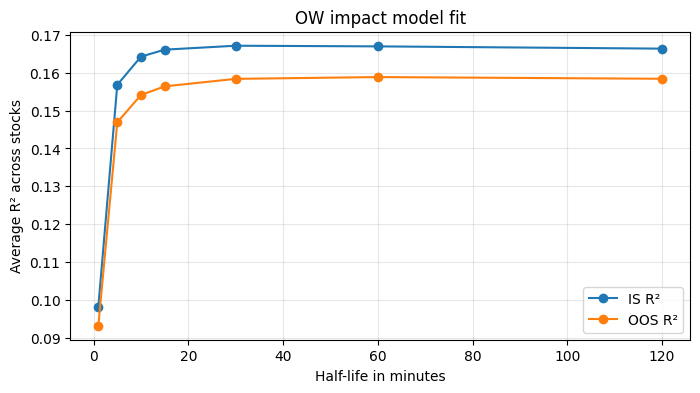

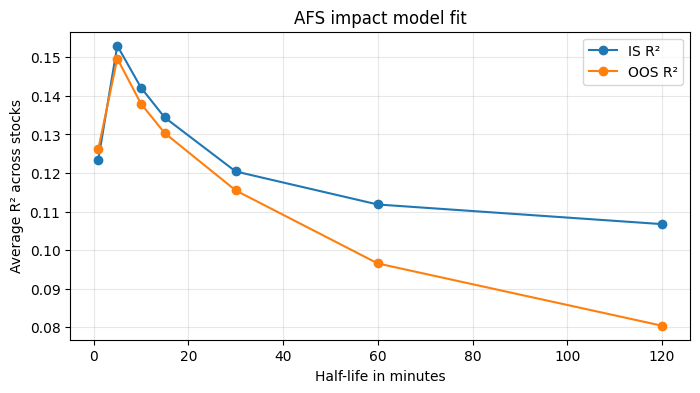

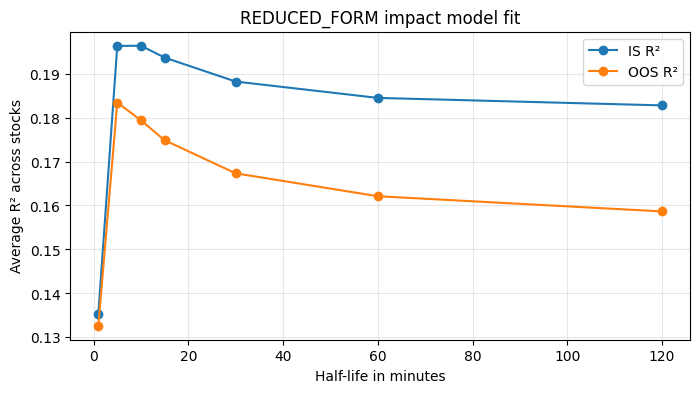

In [30]:
# Plot the results
for model_type in ["ow", "afs", "reduced_form"]:
    sub = grid_summary[grid_summary["model_type"] == model_type]

    plt.figure(figsize=(8, 4))
    plt.plot(sub["half_life_minutes"], sub["mean_is_r2"], marker="o", label="IS R²")
    plt.plot(sub["half_life_minutes"], sub["mean_oos_r2"], marker="o", label="OOS R²")
    plt.xlabel("Half-life in minutes")
    plt.ylabel("Average R² across stocks")
    plt.title(f"{model_type.upper()} impact model fit")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

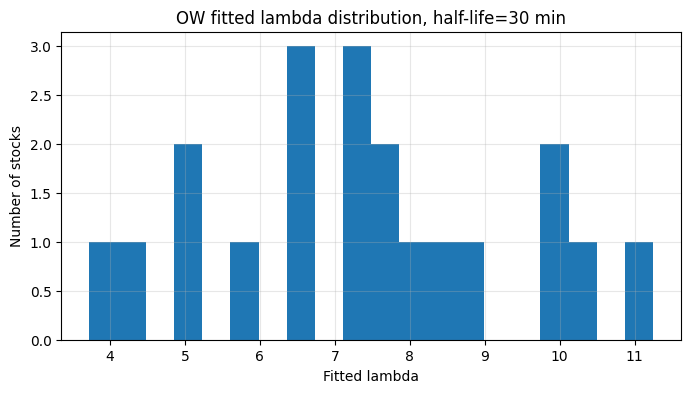

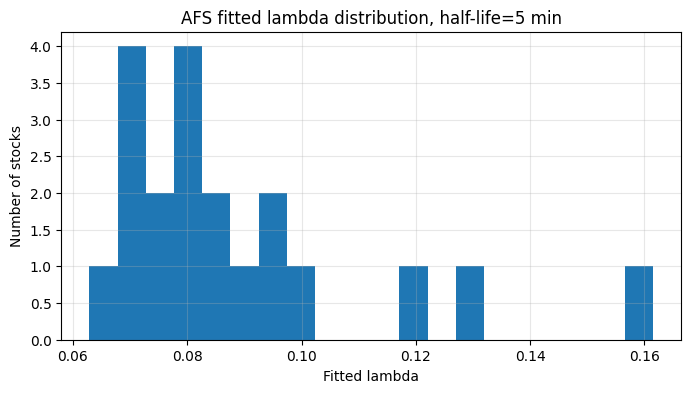

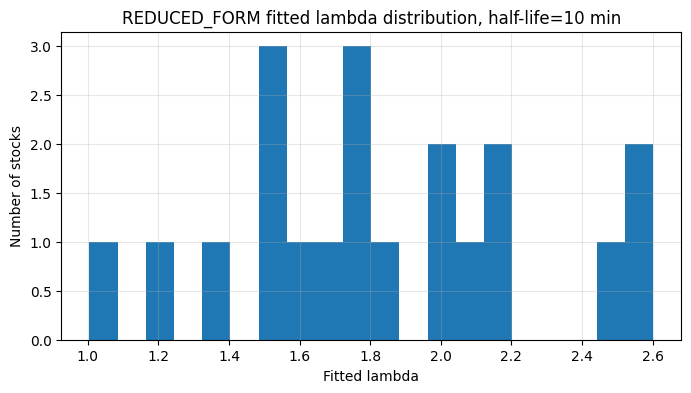

In [31]:
# Plot the distribution of fitted lambda values for the best half-life for each model
for model_type in ["ow", "afs", "reduced_form"]:
    sub = all_results_df[all_results_df["model_type"] == model_type]

    best_half_life = (
        best_by_is
        .loc[best_by_is["model_type"] == model_type, "half_life_minutes"]
        .iloc[0]
    )

    best_half_life_seconds = int(best_half_life * 60)

    sub_best = sub[sub["half_life_seconds"] == best_half_life_seconds]

    plt.figure(figsize=(8, 4))
    plt.hist(sub_best["lambda_hat"], bins=20)
    plt.xlabel("Fitted lambda")
    plt.ylabel("Number of stocks")
    plt.title(
        f"{model_type.upper()} fitted lambda distribution, "
        f"half-life={best_half_life:.0f} min"
    )
    plt.grid(True, alpha=0.3)
    plt.show()